In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df= pd.read_csv("Zomato data .csv")
# print(df)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [9]:
#Data Cleaning
#Remove /5 from rating rate
def handlerate(value):
    value= str(value).split("/")
    value=value[0]
    return float(value)
df["rate"]=df["rate"].apply(handlerate) 
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


Text(0.5, 0, 'Type of Resturant')

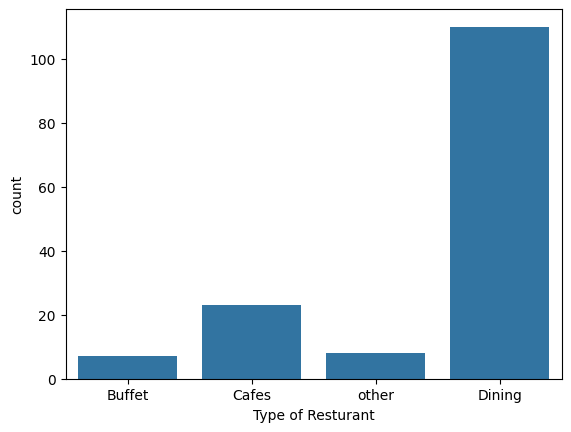

In [11]:
#Type of Restourant
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of Resturant")
#conclusion-Maximum order from dining category

Text(0, 0.5, 'Votes')

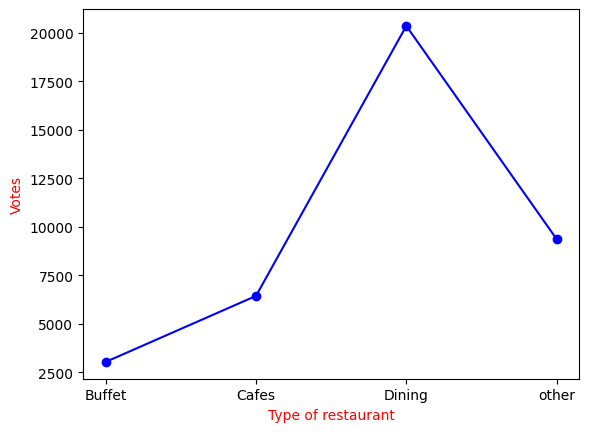

In [20]:
#Which restourant got highest votes
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})  # Use DataFrame instead of df
plt.plot(result, c="blue", marker="o")
plt.xlabel("Type of restaurant", c="red", size=10)
plt.ylabel("Votes", c="red", size=10)
#Dining Resturant got maximum votes


In [21]:
df.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


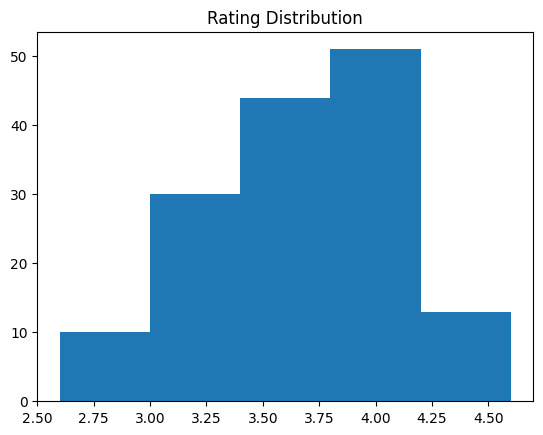

In [24]:
plt.hist(df["rate"],bins= 5)
plt.title("Rating Distribution")
plt.show()
# Majority Restourants got rating 3.5 to 4

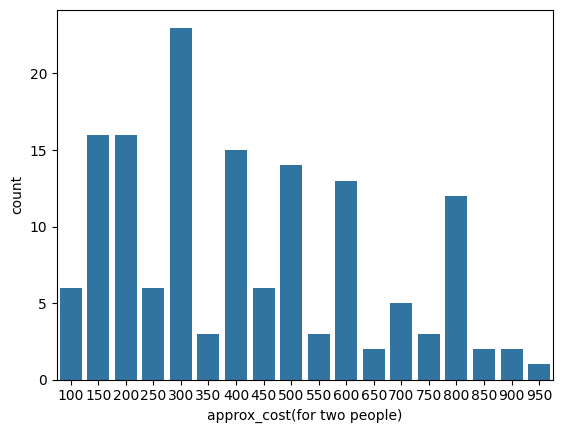

In [26]:
#Average order spent by couple
sns.countplot(x=df["approx_cost(for two people)"])
plt.show()
Conclusion:Majority of couples prefer resturants with an approx cost of 300 rupees

<Axes: xlabel='online_order', ylabel='rate'>

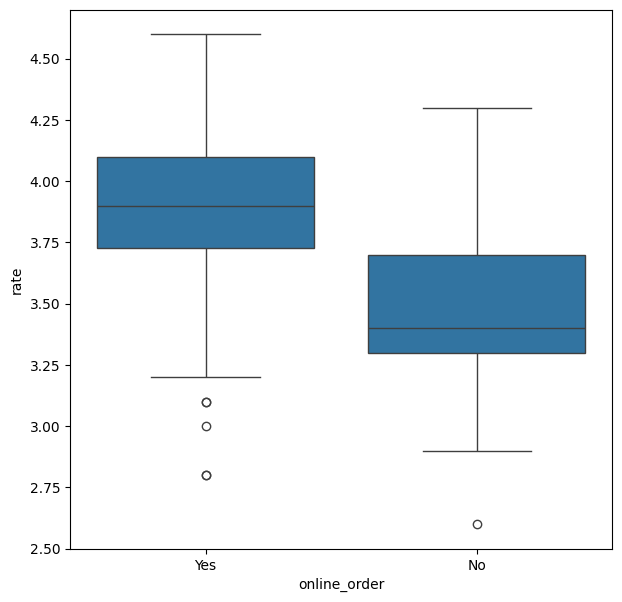

In [28]:
#Which mode receives maximum ratings
# df.head()
plt.figure(figsize= (7,7))
sns.boxplot(x='online_order',y='rate',data= df)
#conclusion: Offline order receives less rating as compare to online order

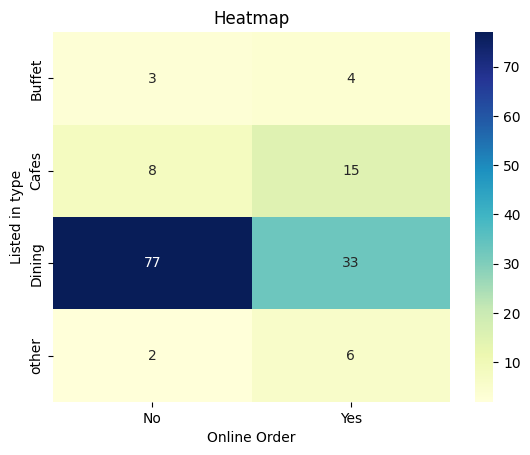

In [33]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed in type")
plt.show()
#Dining restaurants primarily accept offline orders,whereas cafes primarily receive online orders,
#This suggests that clients prefer orders in person at restaurants,but prefer online ordering at cafes.
